# Machine Learning - Chapter 4
# Exploratory Data Analysis (EDA) & Data Visualization

## What is EDA?

Exploratory Data Analysis (EDA) is the process of analyzing datasets to summarize their characteristics using statistics and visualizations.

### Why EDA?

EDA helps us:

- Understand data structure
- Detect missing values
- Find outliers
- Identify trends and patterns
- Discover relationships between variables
- Improve feature selection
- Prepare data for Machine Learning

### EDA Workflow

```text
Data Collection
      ↓
Load Dataset
      ↓
Data Inspection
      ↓
Data Cleaning
      ↓
Statistical Analysis
      ↓
Visualization
      ↓
Insights
```

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Sample Dataset

We will use a simple student dataset for understanding EDA.

Features:

- Name
- Age
- Gender
- Marks
- Attendance

In [2]:
data = {
    "Name":["John","Alice","Bob","David","Emma"],
    "Age":[20,21,22,20,23],
    "Gender":["Male","Female","Male","Male","Female"],
    "Marks":[85,92,78,88,95],
    "Attendance":[90,95,80,85,98]
}

df = pd.DataFrame(data)

df

,Name,Age,Gender,Marks,Attendance
0,John,20,Male,85,90
1,Alice,21,Female,92,95
2,Bob,22,Male,78,80
3,David,20,Male,88,85
4,Emma,23,Female,95,98


# Viewing Dataset

Useful Pandas Functions:

- head()
- tail()
- shape
- columns
- info()

In [3]:
print("First Five Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

First Five Rows
    Name  Age  Gender  Marks  Attendance
0   John   20    Male     85          90
1  Alice   21  Female     92          95
2    Bob   22    Male     78          80
3  David   20    Male     88          85
4   Emma   23  Female     95          98

Dataset Shape
(5, 5)

Column Names
Index(['Name', 'Age', 'Gender', 'Marks', 'Attendance'], dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        5 non-null      object
 1   Age         5 non-null      int64 
 2   Gender      5 non-null      object
 3   Marks       5 non-null      int64 
 4   Attendance  5 non-null      int64 
dtypes: int64(3), object(2)
memory usage: 332.0+ bytes


# Statistical Summary

The describe() function provides:

- Count
- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

In [5]:
df.describe()

,Age,Marks,Attendance
count,5.00000,5.000000,5.000000
mean,21.20000,87.600000,89.600000
std,1.30384,6.580274,7.300685
min,20.00000,78.000000,80.000000
25%,20.00000,85.000000,85.000000
50%,21.00000,88.000000,90.000000
75%,22.00000,92.000000,95.000000
max,23.00000,95.000000,98.000000


# Missing Values Analysis

Missing values can negatively affect ML models.

### Checking Missing Values

isnull()

sum()

In [6]:
df.isnull().sum()

Name          0
Age           0
Gender        0
Marks         0
Attendance    0
dtype: int64

# Unique Values

Useful for understanding categorical features.

Functions:

- unique()
- nunique()

In [7]:
print(df["Gender"].unique())

print("Unique Values:", df["Gender"].nunique())

['Male' 'Female']
Unique Values: 2


# Correlation

Correlation measures the relationship between numerical variables.

Range:

- +1 → Strong Positive
- 0 → No Correlation
- -1 → Strong Negative

In [8]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,Age,Marks,Attendance
Age,1.000000,0.215627,0.299403
Marks,0.215627,1.000000,0.911731
Attendance,0.299403,0.911731,1.000000


# Correlation Heatmap

Heatmaps visually represent correlation values.

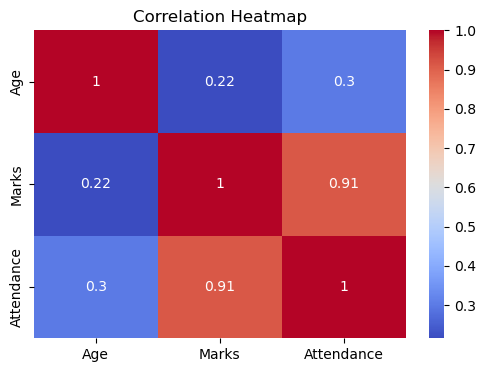

In [9]:
plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Data Visualization

Visualization makes patterns easier to understand.

Common Charts:

1. Histogram
2. Bar Chart
3. Line Chart
4. Scatter Plot
5. Box Plot
6. Pie Chart
7. Heatmap

# Histogram

Shows frequency distribution.

Useful for:

- Understanding spread
- Detecting skewness

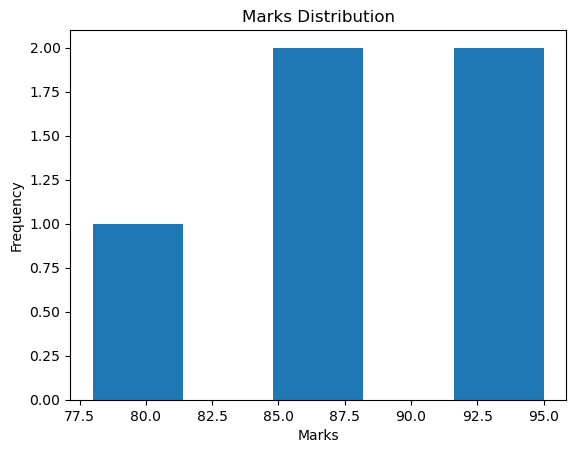

In [10]:
plt.hist(df["Marks"], bins=5)

plt.title("Marks Distribution")
plt.xlabel("Marks")
plt.ylabel("Frequency")

plt.show()

# Bar Chart

Used to compare categories.

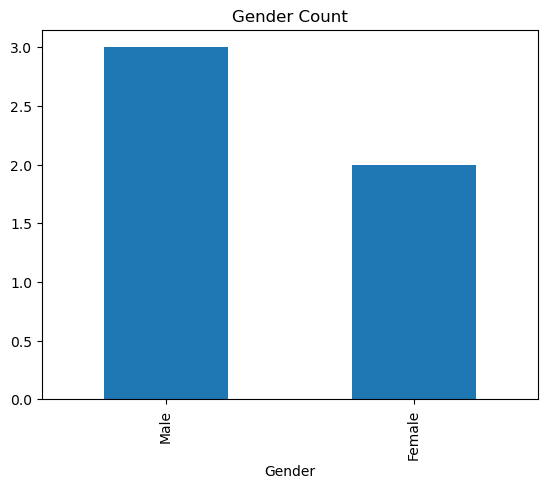

In [11]:
gender_count = df["Gender"].value_counts()

gender_count.plot(kind="bar")

plt.title("Gender Count")
plt.show()

# Line Chart

Used to show trends over time or sequence.

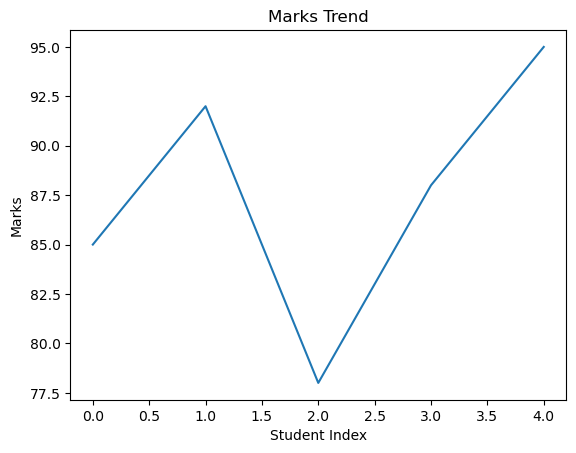

In [12]:
plt.plot(df["Marks"])

plt.title("Marks Trend")
plt.xlabel("Student Index")
plt.ylabel("Marks")

plt.show()

# Scatter Plot

Shows relationship between two numerical variables.

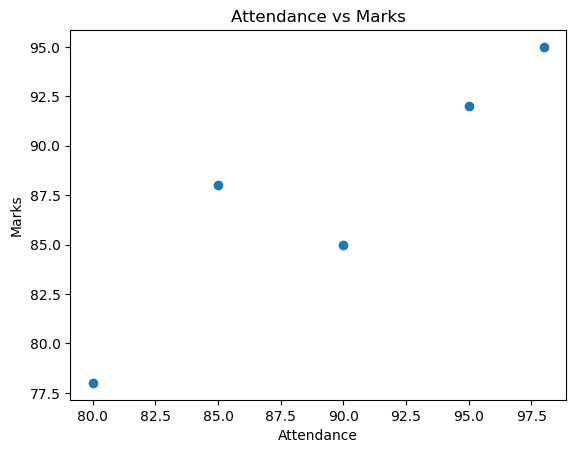

In [13]:
plt.scatter(
    df["Attendance"],
    df["Marks"]
)

plt.xlabel("Attendance")
plt.ylabel("Marks")
plt.title("Attendance vs Marks")

plt.show()

# Box Plot

Used to detect outliers.

### Components

- Minimum
- Q1
- Median
- Q3
- Maximum
- Outliers

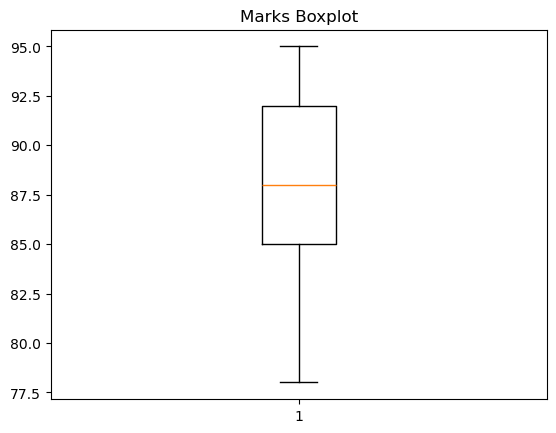

In [14]:
plt.boxplot(df["Marks"])

plt.title("Marks Boxplot")

plt.show()

# Pie Chart

Used to show proportions.

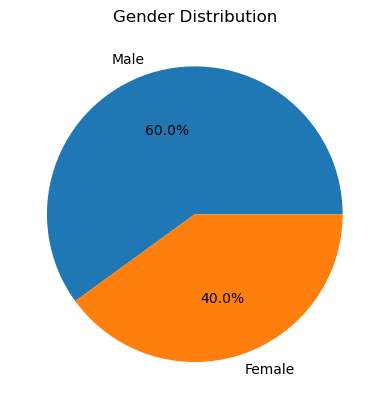

In [15]:
gender_count = df["Gender"].value_counts()

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

# Seaborn Visualizations

Seaborn provides beautiful statistical plots.

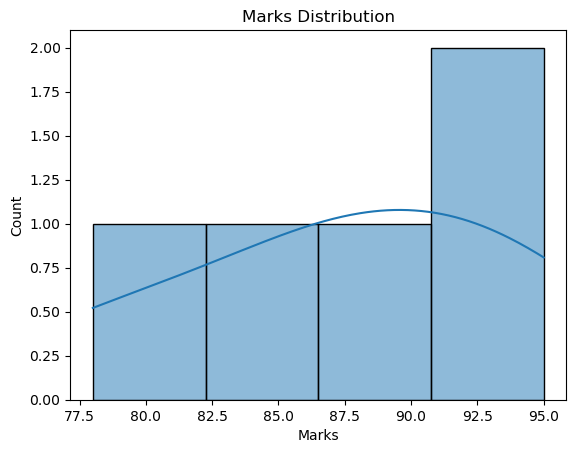

In [16]:
sns.histplot(df["Marks"], kde=True)

plt.title("Marks Distribution")

plt.show()

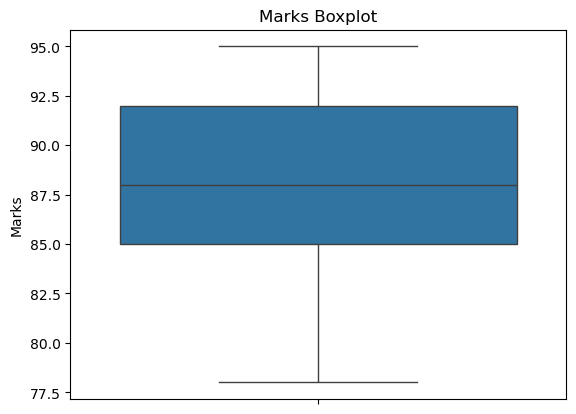

In [17]:
sns.boxplot(y=df["Marks"])

plt.title("Marks Boxplot")

plt.show()

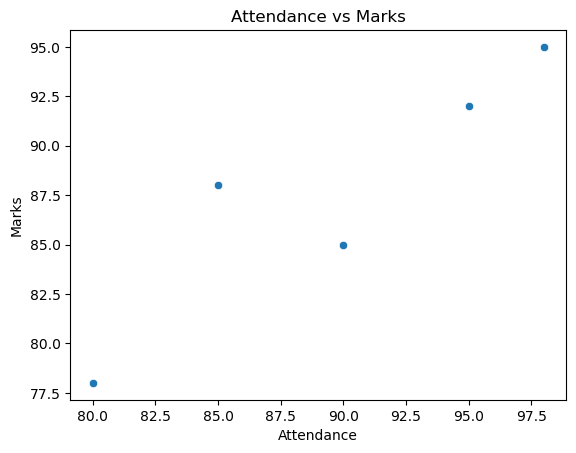

In [18]:
sns.scatterplot(
    x=df["Attendance"],
    y=df["Marks"]
)

plt.title("Attendance vs Marks")

plt.show()

# Pair Plot

Displays relationships between all numerical features.

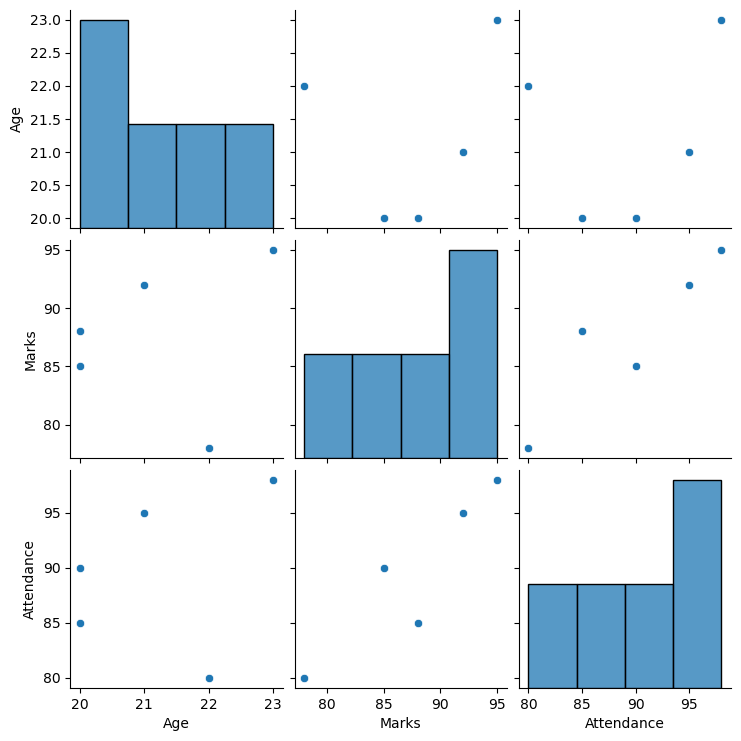

In [19]:
sns.pairplot(df)

plt.show()

# Outlier Detection Using IQR

IQR = Q3 - Q1

Outlier Conditions:

```text
Less than:
Q1 - 1.5 × IQR

Greater than:
Q3 + 1.5 × IQR
```

In [20]:
Q1 = df["Marks"].quantile(0.25)
Q3 = df["Marks"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Marks"] < lower) |
    (df["Marks"] > upper)
]

print(outliers)

Empty DataFrame
Columns: [Name, Age, Gender, Marks, Attendance]
Index: []


# Distribution Analysis

Distribution Types:

### Normal Distribution

Bell-shaped curve.

### Left Skewed

Tail towards left.

### Right Skewed

Tail towards right.

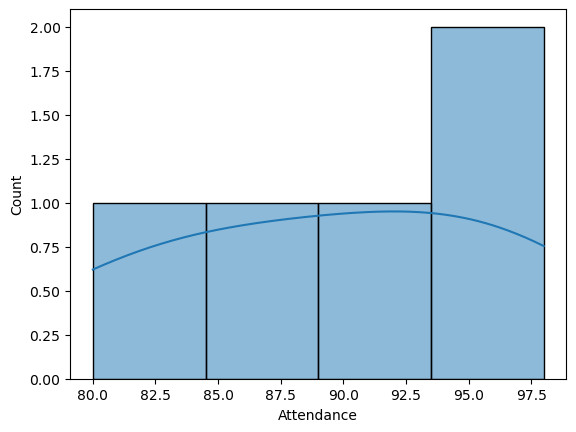

In [21]:
sns.histplot(
    df["Attendance"],
    kde=True
)

plt.show()

# Real-World EDA Process

Example: House Price Dataset

Step 1:
Load Dataset

Step 2:
Check Missing Values

Step 3:
Check Duplicates

Step 4:
Analyze Features

Step 5:
Create Visualizations

Step 6:
Remove Outliers

Step 7:
Find Correlations

Step 8:
Prepare Data for ML

# Best Practices for EDA

✅ Understand business problem

✅ Check data types

✅ Analyze missing values

✅ Detect outliers

✅ Use visualizations

✅ Study correlations

✅ Document insights

✅ Clean data before modeling

# Summary

EDA is a critical step before Machine Learning.

Key Tasks:

1. Inspect Data
2. Analyze Missing Values
3. Generate Statistics
4. Detect Outliers
5. Study Correlations
6. Create Visualizations
7. Extract Insights

Important Libraries:

- Pandas
- NumPy
- Matplotlib
- Seaborn

# Interview & Exam Questions

1. What is EDA?
2. Why is EDA important?
3. What does describe() do?
4. Difference between histogram and bar chart.
5. What is correlation?
6. Explain correlation heatmap.
7. What is a scatter plot?
8. How do you detect outliers?
9. What is IQR?
10. Explain box plots.
11. What is pairplot?
12. What are the benefits of visualization?
13. Difference between Pandas and NumPy.
14. Explain skewness.
15. Describe a complete EDA workflow.